In [82]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib.lines import Line2D

## P1. Carga de datos y construcción del grafo

Red *moreno_blogs* (KONECT): 1.224 blogs sobre las elecciones presidenciales de EE.UU. 2004; una arista $u \to v$ indica que el blog $u$ tiene un hipervínculo hacia el blog $v$. Cada nodo tiene orientación política (*left-leaning* / *right-leaning*).

In [79]:
# 1. RUTAS DE LOS ARCHIVOS 

ruta_aristas = "Datos_blogs/nodos_blogs.txt"
ruta_orientacion = "Datos_blogs/orientacion_blogs.txt"

In [80]:
# 2. LEER ARCHIVO DE ARISTAS
aristas = pd.read_csv(
    ruta_aristas,
    sep=r"\s+",
    comment="%",
    header=None,
    names=["origen", "destino"]
)

print(aristas.head())

   origen  destino
0       1        2
1       1        3
2       1        4
3       1        5
4       1        6


In [81]:
# 3. LEER ORIENTACION POLITICA DE CADA NODO

# para al final sacar una conclusion de la orientacion politica de los nodos de convergencia

orientacion = pd.read_csv(
    ruta_orientacion,
    header=None,
    names=["orientacion"]
)

# como el archivo de orientacion politica esta ordenado le asignamos su nodo correspondiente con su indice + 1
orientacion["nodo"] = range(1, len(orientacion) + 1)

print(orientacion.head())

    orientacion  nodo
0  left-leaning     1
1  left-leaning     2
2  left-leaning     3
3  left-leaning     4
4  left-leaning     5


In [82]:
# 4. CREAR GRAFO DIRIGIDO

G = nx.from_pandas_edgelist(
    aristas,
    source="origen",
    target="destino",
    create_using=nx.DiGraph()
)

# Propiedades utiles de G:
# G.number_of_nodes() -> numero de nodos
# G.number_of_edges() -> numero de aristas
# G.successors(v)     -> nodos a los que apunta v
# G.predecessors(v)   -> nodos que apuntan a v
# G.out_degree(v)     -> grado de salida de v
# G.in_degree(v)      -> grado de entrada de v
# G.nodes[v]          -> atributos del nodo v (ej: "orientacion", agregado abajo)

# nos aseguramos de incluir todos los nodos (por si alguno no aparece en las aristas)
G.add_nodes_from(orientacion["nodo"])

# agregamos la orientacion politica como atributo de cada nodo
dic_orientacion = dict(zip(orientacion["nodo"], orientacion["orientacion"]))
nx.set_node_attributes(G, dic_orientacion, "orientacion")

print("cantidad de nodos:", G.number_of_nodes())
print("cantidad de aristas:", G.number_of_edges())

cantidad de nodos: 1224
cantidad de aristas: 19025


In [83]:
# 5. CREAR TABLA DE NODOS

tabla_nodos = pd.DataFrame({
    "nodo": list(G.nodes()),
    "grado_entrada": [G.in_degree(nodo) for nodo in G.nodes()],
    "grado_salida": [G.out_degree(nodo) for nodo in G.nodes()],
    "orientacion": [G.nodes[nodo].get("orientacion") for nodo in G.nodes()]
})

# un nodo es colgante si no tiene enlaces de salida
tabla_nodos["es_colgante"] = tabla_nodos["grado_salida"] == 0

print(tabla_nodos.head())

   nodo  grado_entrada  grado_salida   orientacion  es_colgante
0     1             12            15  left-leaning        False
1     2             68            29  left-leaning        False
2     3            263            87  left-leaning        False
3     4             57            16  left-leaning        False
4     5            337            46  left-leaning        False


In [84]:
# 6. CREAR LISTA DE VECINOS DE SALIDA

vecinos_salida = {
    nodo: list(G.successors(nodo))
    for nodo in G.nodes() 
}

print("vecinos de salida del nodo 1:")
print(vecinos_salida[1])

vecinos de salida del nodo 1:
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## P3. Análisis exploratorio de la red

### Estadísticas básicas y (a) distribución de grados

In [85]:
n = G.number_of_nodes()
m = G.number_of_edges()

grado_entrada_medio = m / n
grado_salida_medio = m / n
densidad = m / (n * (n - 1))

cantidad_colgantes = tabla_nodos["es_colgante"].sum()
porcentaje_colgantes = cantidad_colgantes / n * 100

print("grado de entrada medio:", grado_entrada_medio)
print("grado de salida medio:", grado_salida_medio)
# la densidad compara las aristas existentes (m) con el maximo posible (n(n-1)):
# aqui es ~0.013, o sea solo el 1.3% de los enlaces posibles existe -> red dispersa (sparse)
print("densidad:", densidad)
print("cantidad de nodos colgantes:", cantidad_colgantes)
print("porcentaje de nodos colgantes:", porcentaje_colgantes)

grado de entrada medio: 15.543300653594772
grado de salida medio: 15.543300653594772
densidad: 0.012709158343086484
cantidad de nodos colgantes: 159
porcentaje de nodos colgantes: 12.990196078431374


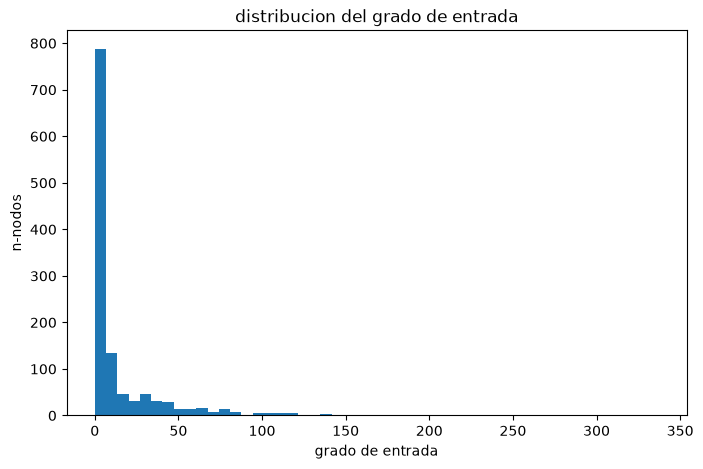

In [86]:
plt.figure(figsize=(8, 5))

plt.hist(tabla_nodos["grado_entrada"], bins=50)

plt.xlabel("grado de entrada")
plt.ylabel("n-nodos")
plt.title("distribucion del grado de entrada")

plt.savefig(f"./figures/p3a_distribucion_grado_entrada.png", dpi=300, bbox_inches="tight")
plt.show()

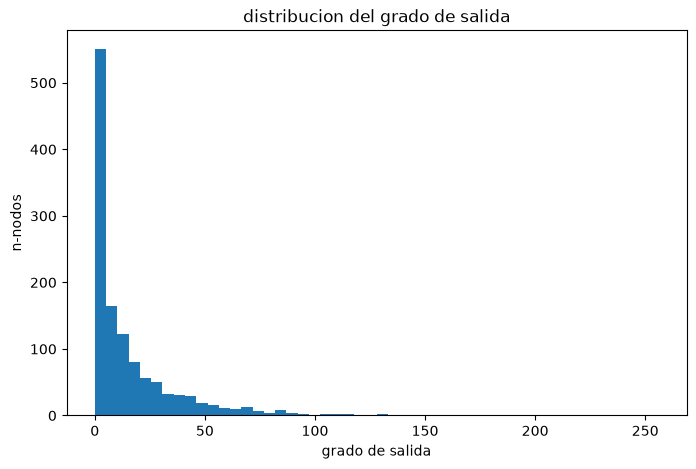

In [87]:
plt.figure(figsize=(8, 5))

plt.hist(tabla_nodos["grado_salida"], bins=50)

plt.xlabel("grado de salida")
plt.ylabel("n-nodos")
plt.title("distribucion del grado de salida")

plt.savefig(f"./figures/p3a_distribucion_grado_salida.png", dpi=300, bbox_inches="tight")
plt.show()

### (b) Nodos colgantes

In [88]:
nodos_colgantes = tabla_nodos[tabla_nodos["grado_salida"] == 0].copy()

print("n nodos colgantes:", len(nodos_colgantes))
print("% de nodos colgantes:", round(len(nodos_colgantes) / n * 100, 2), "%")

display(nodos_colgantes.head(10))

n nodos colgantes: 159
% de nodos colgantes: 12.99 %


,nodo,grado_entrada,grado_salida,orientacion,es_colgante
6,7,8,0,left-leaning,True
20,21,1,0,left-leaning,True
23,24,80,0,left-leaning,True
29,30,45,0,left-leaning,True
52,53,103,0,left-leaning,True
73,74,33,0,left-leaning,True
76,77,82,0,right-leaning,True
87,88,15,0,left-leaning,True
112,113,143,0,right-leaning,True
118,119,52,0,right-leaning,True


Los nodos colgantes son los que tienen grado de salida igual a cero (no apuntan a nada). En esta red corresponden a blogs que no enlazan a ningún otro blog del dataset (159 nodos, un 12,99% del total).

Son problemáticos para PageRank porque generan **columnas de ceros en la matriz de hipervínculos H**: la columna del nodo colgante no suma 1, así que H deja de ser columna-estocástica. En términos del random walk, si el caminante llega a un blog sin enlaces de salida no tiene ningún enlace que seguir, y en la iteración de potencias el vector va "perdiendo" masa de probabilidad.

Esto se resuelve con la matriz columna-estocástica $S = H + \frac{1}{n}\,\mathbf{a}\mathbf{1}^T$, donde $a_j = 1$ si el nodo $j$ es colgante. Es decir, cada columna cero se reemplaza por el vector uniforme $\mathbf{1}/n$: si el caminante cae en un blog sin salidas, salta a cualquier nodo de la red con igual probabilidad. Así todas las columnas de $S$ suman 1.

### (c) Top 10 nodos por grado de entrada y de salida

In [89]:
top_entrada = tabla_nodos.sort_values(
    by="grado_entrada",
    ascending=False
).head(10)

display(top_entrada)

top_entrada.to_csv(f"./resultados/p3c_top_10_grado_entrada.csv", index=False)

,nodo,grado_entrada,grado_salida,orientacion,es_colgante
4,5,337,46,left-leaning,False
117,118,276,86,right-leaning,False
10,11,268,14,left-leaning,False
2,3,263,87,left-leaning,False
182,183,238,5,right-leaning,False
14,15,220,15,right-leaning,False
301,302,211,256,right-leaning,False
93,94,201,55,left-leaning,False
176,177,200,28,right-leaning,False
54,55,187,17,right-leaning,False


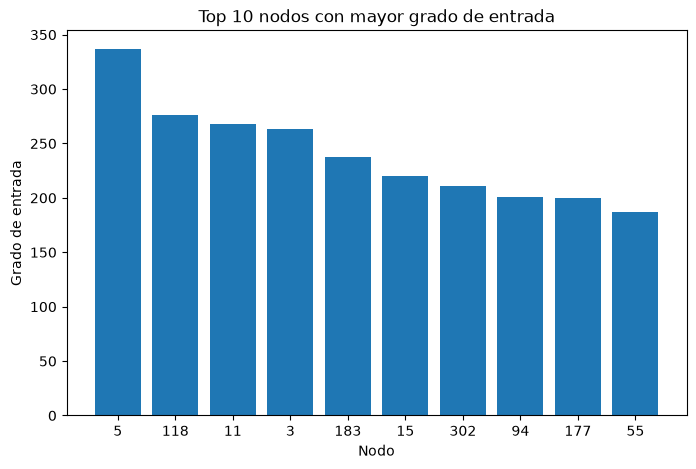

In [90]:
plt.figure(figsize=(8, 5))

plt.bar(top_entrada["nodo"].astype(str), top_entrada["grado_entrada"])

plt.xlabel("Nodo")
plt.ylabel("Grado de entrada")
plt.title("Top 10 nodos con mayor grado de entrada")

plt.savefig(f"./figures/p3c_top_10_grado_entrada.png", dpi=300, bbox_inches="tight")
plt.show()

In [91]:
top_salida = tabla_nodos.sort_values(
    by="grado_salida",
    ascending=False
).head(10)

display(top_salida)

top_salida.to_csv(f"./resultados/p3c_top_10_grado_salida.csv", index=False)

,nodo,grado_entrada,grado_salida,orientacion,es_colgante
301,302,211,256,right-leaning,False
104,105,39,140,left-leaning,False
63,64,39,131,left-leaning,False
65,66,20,131,left-leaning,False
659,660,19,123,right-leaning,False
31,32,101,115,left-leaning,False
538,539,105,113,right-leaning,False
444,445,101,110,right-leaning,False
158,159,17,109,left-leaning,False
22,23,72,106,left-leaning,False


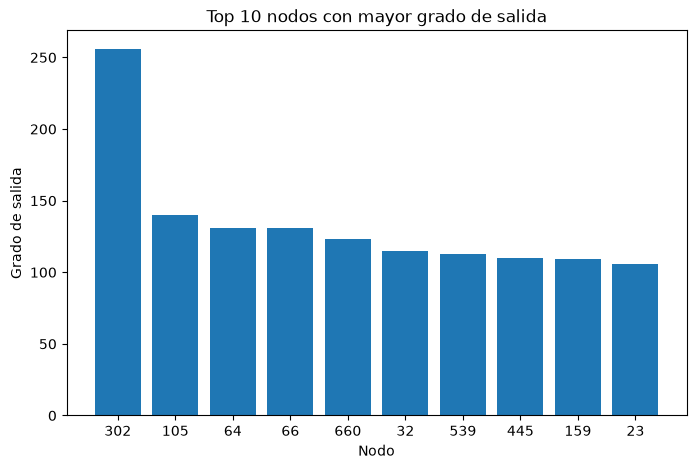

In [92]:
plt.figure(figsize=(8, 5))

plt.bar(top_salida["nodo"].astype(str), top_salida["grado_salida"])

plt.xlabel("Nodo")
plt.ylabel("Grado de salida")
plt.title("Top 10 nodos con mayor grado de salida")

plt.savefig(f"./figures/p3c_top_10_grado_salida.png", dpi=300, bbox_inches="tight")
plt.show()

**Observaciones.** El nodo 5 (left-leaning) domina el grado de entrada (337 enlaces recibidos) y el nodo 302 (right-leaning) domina el grado de salida (256 enlaces emitidos), apareciendo además en ambos rankings.

El top 10 por grado de entrada queda repartido 5-5 entre blogs de izquierda y de derecha, así que a nivel de grado la influencia no parece dominada por un solo sector político. El grado de entrada mide cuántos blogs enlazan a uno (popularidad como referencia), mientras que el grado de salida identifica blogs "difusores" que enlazan mucho al resto. PageRank nos permitirá ver si esta primera impresión se mantiene cuando la importancia de un enlace depende de quién lo emite.

In [93]:
grafo = G.copy()
# ¿es la red fuertemente conexa?
es_fuertemente_conexa = nx.is_strongly_connected(grafo)

# componentes fuertemente conexas: subgrafos donde todo par se alcanza mutuamente
n_componentes_fuertes = nx.number_strongly_connected_components(grafo)
mayor_scc = max(nx.strongly_connected_components(grafo), key=len)

# componentes debilmente conexas: ignorando la direccion de las aristas
n_componentes_debiles = nx.number_weakly_connected_components(grafo)
mayor_wcc = max(nx.weakly_connected_components(grafo), key=len)

print("¿Fuertemente conexa?:", es_fuertemente_conexa)
print("Componentes fuertemente conexas:", n_componentes_fuertes)
print("Tamaño de la mayor SCC:", len(mayor_scc), f"({len(mayor_scc)/n*100:.1f}% de los nodos)")
print("Componentes debilmente conexas:", n_componentes_debiles)
print("Tamaño de la mayor WCC:", len(mayor_wcc), f"({len(mayor_wcc)/n*100:.1f}% de los nodos)")

¿Fuertemente conexa?: False
Componentes fuertemente conexas: 422
Tamaño de la mayor SCC: 793 (64.8% de los nodos)
Componentes debilmente conexas: 2
Tamaño de la mayor WCC: 1222 (99.8% de los nodos)


## P4. Construcción de la Matriz de Google

### Parámetros iniciales

In [94]:
# ========== parametros ==========

# factor de amortiguamiento: probabilidad de seguir un enlace real
# (con prob. 1 - alpha el caminante salta a un nodo cualquiera).
# usamos 0.85, el valor clasico de Brin & Page: balancea respetar la
# estructura de la red con una convergencia rapida (razon ~ alpha)
alpha = 0.85

# tolerancia numerica para verificar sumas de columnas
tol_columnas = 1e-12

# grafo dirigido de NetworkX
grafo = G

# tabla de aristas ya cargada (columnas: origen, destino)
# aristas.head()

### (a) Matriz de hipervínculos H

Definimos $H \in \mathbb{R}^{n \times n}$ con $H_{ij} = \frac{1}{\text{out}(j)}$ si existe el enlace $j \to i$, y $0$ si no.

**¿Por qué cada columna de un nodo no colgante suma 1?** La columna $j$ tiene exactamente $\text{out}(j)$ entradas no nulas (una por cada enlace de salida de $j$), todas iguales a $1/\text{out}(j)$. Su suma es $\text{out}(j) \cdot \frac{1}{\text{out}(j)} = 1$. Esto refleja que el caminante aleatorio parado en $j$ reparte toda su probabilidad en partes iguales entre sus enlaces. Las **columnas cero** son las de los nodos colgantes ($\text{out}(j)=0$): las identificamos calculando la suma de cada columna y buscando las que dan 0.

**Eficiencia.** $H$ tiene solo $m = 19.025$ entradas no nulas de $n^2 \approx 1{,}5$ millones posibles (densidad ~1,3%), así que la guardamos en formato disperso (`csc_matrix`), que almacena solo los no-ceros y hace el producto matriz-vector en $O(m)$ en vez de $O(n^2)$. La construcción es **vectorizada**: en lugar de recorrer las 19 mil aristas una por una con `iterrows` (un loop de Python, lento), mapeamos las columnas completas del DataFrame a índices con `.map()` y armamos los tres arrays (filas, columnas, datos) de una sola vez con operaciones de numpy.

In [95]:
# ordenamos los nodos para que cada nodo tenga una posicion fija en la matriz
nodos_ordenados = sorted(grafo.nodes())
n = len(nodos_ordenados)

# diccionario: nodo real -> indice de matriz
id_a_indice = {nodo: indice for indice, nodo in enumerate(nodos_ordenados)}

# --- construccion VECTORIZADA (sin iterrows) ---
# mapeamos las columnas completas del DataFrame a indices de matriz
indices_origen = aristas["origen"].map(id_a_indice).to_numpy()
indices_destino = aristas["destino"].map(id_a_indice).to_numpy()

# grado de salida como array alineado con los indices de la matriz
grado_salida = np.zeros(n)
for nodo, grado in grafo.out_degree():
    grado_salida[id_a_indice[nodo]] = grado

# el valor de cada entrada es 1/out(origen).
# nota: no hace falta filtrar out == 0, porque si existe la arista (origen -> destino)
# entonces origen tiene al menos ese enlace de salida, o sea out(origen) >= 1
datos = 1.0 / grado_salida[indices_origen]

# H[destino, origen] = 1/out(origen): destino en la fila, origen en la columna
H = csc_matrix((datos, (indices_destino, indices_origen)), shape=(n, n))

print("Dimension de H:", H.shape)
print("Cantidad de nodos:", n)
print("Cantidad de entradas no cero en H:", H.nnz)

Dimension de H: (1224, 1224)
Cantidad de nodos: 1224
Cantidad de entradas no cero en H: 19025


**Verificación:** las columnas cero de H deben coincidir exactamente con los 159 nodos colgantes identificados en P3(b).

In [96]:
suma_columnas_H = np.array(H.sum(axis=0)).flatten()

columnas_cero_H = np.where(np.abs(suma_columnas_H) < tol_columnas)[0]
cantidad_columnas_cero_H = len(columnas_cero_H)

print("Cantidad de columnas cero en H:", cantidad_columnas_cero_H)
print("Primeras 20 sumas de columnas de H:")
print(suma_columnas_H[:20])

Cantidad de columnas cero en H: 159
Primeras 20 sumas de columnas de H:
[1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### (b) Matriz columna-estocástica S

Reparamos los nodos colgantes reemplazando cada columna cero de $H$ por el vector uniforme $\mathbf{1}/n$:

$$S = H + \frac{1}{n}\,\mathbf{1}\,\mathbf{a}^T, \qquad a_j = \begin{cases} 1 & \text{si } j \text{ es colgante} \\ 0 & \text{si no}\end{cases}$$

**Justificación:** si el caminante llega a un blog sin enlaces de salida, el modelo asume que salta a cualquier página de la red con probabilidad $1/n$. Con esto toda columna de $S$ suma 1, es decir, $S$ es columna-estocástica y define una cadena de Markov válida.

**Nota de eficiencia:** la corrección $\frac{1}{n}\mathbf{1}\mathbf{a}^T$ llena por completo las 159 columnas colgantes ($159 \times 1224 \approx 195$ mil entradas nuevas, 10 veces los no-ceros de $H$). Aquí construimos $S$ explícita **solo para verificar** que sus columnas suman 1; para la iteración de potencias usaremos la forma factorizada (ver (c)), que nunca materializa esta corrección.

In [97]:
# columnas cero de H = nodos colgantes
columnas_colgantes = columnas_cero_H
k = len(columnas_colgantes)

# construccion VECTORIZADA de la correccion (1/n) * 1 a^T:
# para cada columna colgante agregamos el valor 1/n en las n filas
filas_S = np.tile(np.arange(n), k)              # [0..n-1, 0..n-1, ...] k veces
columnas_S = np.repeat(columnas_colgantes, n)   # cada columna colgante repetida n veces
datos_S = np.full(n * k, 1.0 / n)

correccion_colgantes = csc_matrix(
    (datos_S, (filas_S, columnas_S)),
    shape=(n, n)
)

S = H + correccion_colgantes

print("Dimension de S:", S.shape)
print("Cantidad de entradas no cero en S:", S.nnz)

Dimension de S: (1224, 1224)
Cantidad de entradas no cero en S: 213641


Verificación: todas las columnas de S deben sumar 1.

In [98]:
suma_columnas_S = np.array(S.sum(axis=0)).flatten()

print("Minima suma de columna en S:", suma_columnas_S.min())
print("Maxima suma de columna en S:", suma_columnas_S.max())

columnas_malas = np.where(np.abs(suma_columnas_S - 1) > tol_columnas)[0]

print("Cantidad de columnas que no suman 1:", len(columnas_malas))
print("Primeras 20 sumas de columnas de S:")
print(suma_columnas_S[:20])

Minima suma de columna en S: 0.9999999999999996
Maxima suma de columna en S: 1.0000000000000002
Cantidad de columnas que no suman 1: 0
Primeras 20 sumas de columnas de S:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### (c) Matriz de Google G

$$G = \alpha S + \frac{1-\alpha}{n}\,\mathbf{1}\mathbf{1}^T$$

**Elección de $\alpha$:** usamos $\alpha = 0{,}85$, el valor clásico de Brin y Page. Controla el balance entre seguir la estructura real de la red (probabilidad $\alpha$) y teletransportarse a un nodo aleatorio (probabilidad $1-\alpha$). Valores cercanos a 1 respetan más los hipervínculos reales pero hacen la convergencia más lenta (la razón de convergencia de la iteración de potencias es $\approx \alpha$); valores bajos convergen rápido pero "aplanan" el ranking hacia lo uniforme. $0{,}85$ es el compromiso estándar en la literatura.

**¿Por qué todas las entradas de $G$ son estrictamente positivas?** Toda entrada de $S$ es $\geq 0$ y el término de teletransporte aporta $\frac{1-\alpha}{n} > 0$ en **todas** las posiciones, así que $G_{ij} \geq \frac{1-\alpha}{n} > 0$. Esto garantiza que $G$ es irreducible y aperiódica (ergódica) sin importar la estructura del grafo, y por Perron–Frobenius la iteración de potencias converge a un único vector estacionario positivo.

**Por qué NO construimos $G$ explícitamente:** el término $\mathbf{1}\mathbf{1}^T$ hace que $G$ sea **totalmente densa**: $n^2 \approx 1{,}5$ millones de entradas aquí, e imposible de almacenar para redes de millones de nodos (la web real). No hace falta: para la iteración de potencias solo necesitamos el producto $G\mathbf{r}$, que se factoriza usando $S = H + \frac{1}{n}\mathbf{1}\mathbf{a}^T$:

$$G\mathbf{r} = \alpha H\mathbf{r} + \Big(\alpha\,(\mathbf{a}^T\mathbf{r}) + (1-\alpha)\,\textstyle\sum_i r_i\Big)\frac{\mathbf{1}}{n}$$

donde $\mathbf{a}^T\mathbf{r}$ es la masa de probabilidad en los colgantes. Cada producto cuesta $O(m + n)$ (con $H$ dispersa) en vez de $O(n^2)$ con la matriz densa: ~20 mil operaciones vs ~1,5 millones por iteración.

In [99]:
# vector indicador de nodos colgantes
a = np.zeros(n)
a[columnas_colgantes] = 1.0

def multiplicar_google(r):
    """Calcula G r SIN construir G (ni S) explicitamente.

    G r = alpha * H r                         <- seguir enlaces reales
        + alpha * (a . r) / n  * 1            <- colgantes reparten uniforme
        + (1 - alpha) * sum(r) / n * 1        <- teletransporte

    Costo: O(m + n) por producto, gracias a que H es dispersa.
    """
    masa_colgante = a @ r
    return alpha * (H @ r) + (alpha * masa_colgante + (1 - alpha) * r.sum()) / n

print("funcion multiplicar_google definida (G nunca se materializa)")
print("no-ceros de H usados por producto:", H.nnz)
print("entradas que tendria G densa:", n * n)

funcion multiplicar_google definida (G nunca se materializa)
no-ceros de H usados por producto: 19025
entradas que tendria G densa: 1498176


**Verificación:** aunque no construimos $G$, podemos verificar sus propiedades a través del producto:
(i) columna-estocástica $\iff$ $\sum_i (G\mathbf{r})_i = \sum_i r_i$ para todo $\mathbf{r} \geq 0$;
(ii) positividad: la columna $j$ de $G$ es $G\mathbf{e}_j$, y toda entrada debe ser $\geq \frac{1-\alpha}{n}$.

In [100]:
rng = np.random.default_rng(0)

# (i) estocasticidad: G r debe preservar la suma de r
errores = []
for _ in range(10):
    r = rng.random(n)
    errores.append(abs(multiplicar_google(r).sum() - r.sum()))
print("max |sum(G r) - sum(r)| en 10 vectores aleatorios:", max(errores))

# (ii) positividad: probamos columnas canonicas e_j (columna j de G)
minimos = []
for j in rng.integers(0, n, 10):
    e = np.zeros(n)
    e[j] = 1.0
    minimos.append(multiplicar_google(e).min())
print("minima entrada observada en 10 columnas de G:", min(minimos))
print("cota teorica (1 - alpha)/n:", (1 - alpha) / n)
print("todas las entradas positivas:", min(minimos) > 0)

max |sum(G r) - sum(r)| en 10 vectores aleatorios: 1.1368683772161603e-13
minima entrada observada en 10 columnas de G: 0.00012254901960784316
cota teorica (1 - alpha)/n: 0.00012254901960784316
todas las entradas positivas: True


## P5 Cálculo del PageRank mediante iteracion de potencias

### (a) Iteracion

Partimos del vector uniforme $\mathbf{r}^{(0)} = \mathbf{1}/n$ (el caminante puede estar en cualquier blog con igual probabilidad) e iteramos

$$\mathbf{r}^{(k+1)} = G\,\mathbf{r}^{(k)}$$

usando la función `multiplicar_google` (producto factorizado, $O(m+n)$ por iteración, sin construir $G$). El criterio de parada es $\|\mathbf{r}^{(k+1)} - \mathbf{r}^{(k)}\|_1 < \varepsilon$ con $\varepsilon = 10^{-10}$: detenemos cuando el vector prácticamente deja de cambiar.

Guardamos el historial de iterados para poder graficar la curva de convergencia en (b).

In [101]:
epsilon = 1e-10

# r^(0): vector uniforme
r = np.full(n, 1.0 / n)

historial_r = [r] # guardamos cada r^(k) para la curva de convergencia
errores_consecutivos = [] #||r^(k+1) - r^(k)||_1

while True:
    r_nuevo = multiplicar_google(r)
    error = np.abs(r_nuevo -r).sum()

    errores_consecutivos.append(error)
    historial_r.append(r_nuevo)
    r = r_nuevo

    if error < epsilon:
        break

r_estrella = r # Vector de PageRank
iteraciones = len(errores_consecutivos)

print("Iteraciones necesarias:", iteraciones)
print("Error final:", errores_consecutivos[-1])


Iteraciones necesarias: 108
Error final: 8.748334817524663e-11


### (b) Curva de convergencia

Graficamos $\|\mathbf{r}^{(k)} - \mathbf{r}^*\|_1$ en función de $k$, en escala logarítmica. La teoría dice que la iteración de potencias converge geométricamente con razón $|\lambda_2|$, el segundo valor propio de $G$ en módulo, y que para la Matriz de Google $|\lambda_2| \leq \alpha$. En escala log, un decaimiento geométrico $C\alpha^k$ es una **recta** de pendiente $\log\alpha$, agregamos esa recta de referencia para comparar y estimamos la razón empírica como el cociente entre errores sucesivos.

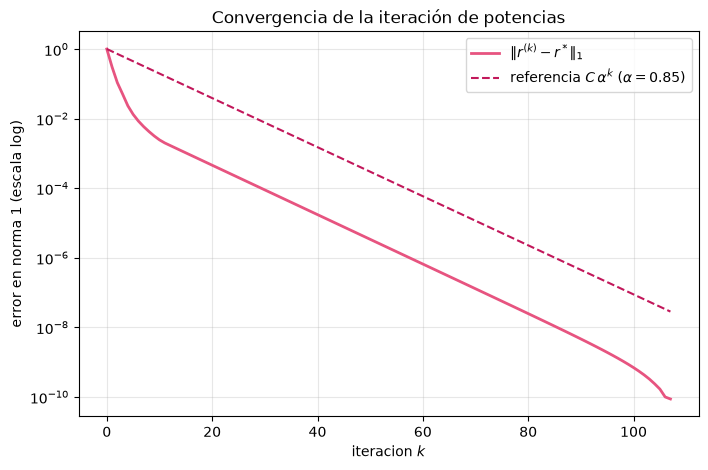

razon de decaimiento empirica: 0.8378
alpha (cota teorica): 0.85


In [102]:
# paleta rosada para figuras hechas por mi:)
rosado_1 = "#c2185b"
rosado_2 = "#e75480"
rosado_3 = "#f8bbd0"

# error de cada iterado respecto del limite r*
errores_vs_limite = [np.abs(r_k - r_estrella).sum() for r_k in historial_r[:-1]]
ks = np.arange(len(errores_vs_limite))

# razon empirica de decaimiento: promedio de errores[k+1]/errores[k]
# (descartamos las priemras y ultimas iteraciones porque son menos representativas)
razones = [errores_vs_limite[k+1] / errores_vs_limite[k] 
           for k in range(len(errores_vs_limite) - 1)
           if errores_vs_limite[k] > 1e-13]

razon_empirica = np.mean(razones[5:-5])

plt.figure(figsize=(8,5))
plt.semilogy(ks, errores_vs_limite, color=rosado_2, linewidth=2,
            label=r"$\|r^{(k)} - r^*\|_1$")
plt.semilogy(ks, errores_vs_limite[0] * alpha**ks, "--", color=rosado_1,
            label=fr"referencia $C\,\alpha^k$ ($\alpha={alpha}$)")
plt.xlabel("iteracion $k$")
plt.ylabel("error en norma 1 (escala log)")
plt.title("Convergencia de la iteración de potencias")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"./figures/p5b_convergencia.png", dpi=300, bbox_inches="tight")
plt.show()

print("razon de decaimiento empirica:", round(razon_empirica, 4))
print("alpha (cota teorica):", alpha)

### (c) Veridicacion de las propiedades de $\mathbf{r}^*$

Comprobamos que $\|\mathbf{r}^*\|_1 = 1$ y que $r^*_i > 0$ para todo $i$. Ambas están garantizadas por que se cumpla lo siguiente:

1. **La suma se conserva en cada iteración**: como $G$ es columna-estocástica, $\mathbf{1}^T G = \mathbf{1}^T$, luego $\mathbf{1}^T\mathbf{r}^{(k+1)} = \mathbf{1}^T G\,\mathbf{r}^{(k)} = \mathbf{1}^T\mathbf{r}^{(k)}$. Partimos de $\mathbf{1}^T\mathbf{r}^{(0)} = 1$, así que todos los iterados (y el límite) suman 1. Esto tiene sentido: $\mathbf{r}^*$ es una distribución de probabilidad sobre los blogs.

2. **Positividad**: $\mathbf{r}^{(0)} > 0$ y $G > 0$, así que cada iterado es positivo. Además, por Perron–Frobenius, el vector propio dominante de una matriz positiva es estrictamente positivo; de hecho $r^*_i \geq \frac{1-\alpha}{n}$ (todo blog recibe al menos la probabilidad del teletransporte).

In [103]:
print("||r*||_1 =", np.abs(r_estrella).sum())
print("r*_i > 0 para todo i:", bool((r_estrella > 0).all()))
print("minimo r*_i:", r_estrella.min())
print("cota teorica (1 - alpha)/n:", (1 - alpha) / n)

||r*||_1 = 0.9999999999999987
r*_i > 0 para todo i: True
minimo r*_i: 0.00019706779743523494
cota teorica (1 - alpha)/n: 0.00012254901960784316


### (d) Top 20 nodos por PageRank

Agregamos el PageRank a la tabla de nodos (mapeando cada nodo a su índice de la matriz con id_a_indice) y presentamos los 20 con mayor puntaje, con su rango, orientación política y grados. 

La tabla resultante se guardará en resultados/.

In [104]:
tabla_pagerank = tabla_nodos.copy()

In [105]:

tabla_pagerank["pagerank"] = [r_estrella[id_a_indice[nodo]] for nodo in tabla_pagerank["nodo"]]

top_20_pagerank = (tabla_pagerank
                  .sort_values(by="pagerank", ascending=False)
                  .head(20)
                  .reset_index(drop=True))

top_20_pagerank.insert(0, "rango", [f"top-{i+1}" for i in range(len(top_20_pagerank))])

columnas = ["rango", "nodo", "orientacion", "pagerank", "grado_entrada", "grado_salida"]
display(top_20_pagerank[columnas])

top_20_pagerank[columnas].to_csv(f"./resultados/p5d_top_20_pagerank.csv", index=False)

# de paso: ¿Como se reparte el top 20 por orientacion

,rango,nodo,orientacion,pagerank,grado_entrada,grado_salida
0,top-1,5,left-leaning,0.018836,337,46
1,top-2,3,left-leaning,0.015986,263,87
2,top-3,118,right-leaning,0.013252,276,86
3,top-4,302,right-leaning,0.013112,211,256
4,top-5,11,left-leaning,0.013052,268,14
5,top-6,177,right-leaning,0.011452,200,28
6,top-7,183,right-leaning,0.011244,238,5
7,top-8,94,left-leaning,0.011070,201,55
8,top-9,15,right-leaning,0.009379,220,15
9,top-10,113,right-leaning,0.009041,143,0


### P6. PageRank vs. grado de entrada
(a) Gráfico y correlación de Pearson
Esta celda calculará la correlación estadística entre ambas métricas y generará el gráfico de dispersión destacando a los 10 nodos más importantes, manteniendo la paleta de colores que definiste antes.

Coeficiente de correlacion de Pearson: 0.9555


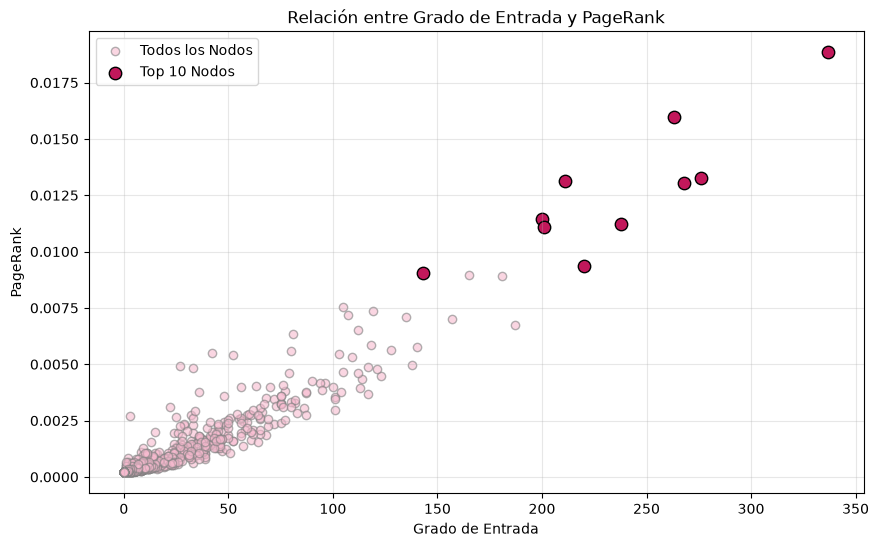

In [106]:
# Calculando el coeficiente de correlacion de Pearson 
correlacion , p_valor = stats.pearsonr(tabla_pagerank["grado_entrada"], tabla_pagerank["pagerank"])
print(f"Coeficiente de correlacion de Pearson: {correlacion:.4f}")

top_10 = top_20_pagerank.head(10)

#Graficando 
plt.figure(figsize=(10, 6))
plt.scatter(tabla_pagerank["grado_entrada"], tabla_pagerank["pagerank"], color=rosado_3, alpha=0.6, edgecolors='grey', label='Todos los Nodos')
plt.scatter(top_10["grado_entrada"], top_10["pagerank"], color=rosado_1, s = 80, edgecolors='black', label='Top 10 Nodos')
plt.xlabel("Grado de Entrada")
plt.ylabel("PageRank")
plt.title("Relación entre Grado de Entrada y PageRank")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"./figures/p5d_grado_vs_pagerank.png", dpi=300, bbox_inches="tight")
plt.show()

## (b) Identificación de anomalías (Diferencias significativas)
Para responder a la segunda parte de esta pregunta, necesitamos encontrar nodos donde el modelo de PageRank y el simple conteo de hipervínculos difieran. Esta celda filtrará candidatos automáticamente para que puedas comentarlos en tu informe.

In [107]:
# Candatos con alto grado de entrada pero PageRank bajo 
top_indegree = tabla_pagerank.sort_values(by="grado_entrada", ascending=False).head(20)
anomalias_bajos = top_indegree.sort_values(by="pagerank", ascending=True).head(5)

# Candidatos con alto PageRank pero moderado grado de entrada
top_pagerank = tabla_pagerank.sort_values(by="pagerank", ascending=False).head(20)
anomalias_altos = top_pagerank.sort_values(by="grado_entrada", ascending=True).head(5)
print("Candidatos con alto grado de entrada pero PageRank bajo:")
display(anomalias_bajos[["nodo", "orientacion", "grado_entrada", "pagerank"]])
print("\nCandidatos con alto PageRank pero moderado grado de entrada:")
display(anomalias_altos[["nodo", "orientacion", "grado_entrada", "pagerank"]])  


Candidatos con alto grado de entrada pero PageRank bajo:


,nodo,orientacion,grado_entrada,pagerank
107,108,left-leaning,123,0.004458
402,403,right-leaning,121,0.004771
126,127,right-leaning,138,0.004946
50,51,left-leaning,128,0.005643
11,12,left-leaning,140,0.005779



Candidatos con alto PageRank pero moderado grado de entrada:


,nodo,orientacion,grado_entrada,pagerank
188,189,right-leaning,81,0.006327
124,125,right-leaning,105,0.007529
221,222,right-leaning,107,0.007167
82,83,left-leaning,112,0.006539
461,462,right-leaning,119,0.007348


Al analizar los resultados, confirmamos que el PageRank captura una dimensión de la influencia que el grado de entrada (in-degree) ignora: **la calidad y exclusividad de los enlaces recibidos, no solo la cantidad.**

A continuación, analizamos dos casos concretos extraídos de nuestras tablas:

* **Caso 1: Alta popularidad, pero baja influencia (Ej. Nodo 127)**
    * **Datos:** Es un blog de derecha (right-leaning) con un alto grado de entrada (138 enlaces recibidos), pero su PageRank es relativamente bajo (0.0049).
    * **Explicación analítica:** Aunque este blog es muy "popular" y citado, los enlaces que recibe provienen probablemente de nodos periféricos o con muy bajo PageRank. Alternativamente, podría estar recibiendo enlaces de nodos importantes, pero que a su vez enlazan a cientos de otros blogs, diluyendo severamente el "peso" (PageRank) que le logran transmitir (debido a la división por el grado de salida en la matriz).
    
* **Caso 2: Popularidad moderada, pero alta influencia (Ej. Nodo 189)**
    * **Datos:** Es un blog de derecha (right-leaning) con un grado de entrada moderado (solo 81 enlaces recibidos, casi la mitad que el Nodo 127), pero ostenta un PageRank notablemente superior (0.0063).
    * **Explicación analítica:** Este blog está posicionado de forma mucho más estratégica en la red. Los pocos enlaces que recibe provienen de blogs sumamente influyentes (con alto PageRank). Además, es probable que esos blogs influyentes tengan pocos enlaces de salida, por lo que le transmiten una fracción muy grande y concentrada de su importancia.

**Conclusión:** Esta diferencia demuestra que en la red de blogs políticos de 2004, no basta con ser citado por muchos sitios pequeños; la verdadera centralidad la otorgan las "citas" de los líderes de opinión de la red. Un solo hipervínculo de un blog altamente influyente vale mucho más que decenas de enlaces de blogs desconocidos.

## P7. Interpretación de resultados

### (a) y (c) Análisis de los nodos de mayor PageRank y distribución por grupos

Primero, analizamos estadísticamente cómo se distribuyen las orientaciones políticas (*left-leaning* y *right-leaning*) entre los blogs más centrales de la red (Top 20 y Top 50), lo que nos permitirá evaluar si la influencia está concentrada en un solo bloque o distribuida equitativamente.

In [81]:
# Obtener los top 50 nodos con mayor PageRank
top_50_pagerank = tabla_pagerank.sort_values(by="pagerank", ascending=False).head(50)
print("--Distribucion politica en el Top 20--")
print(top_20_pagerank["orientacion"].value_counts())
print(top_20_pagerank["orientacion"].value_counts(normalize=True) * 100)

print("\n--Distribucion politica en el Top 50--")
print(top_50_pagerank["orientacion"].value_counts())
print(top_50_pagerank["orientacion"].value_counts(normalize=True) * 100)

--Distribucion politica en el Top 20--
orientacion
right-leaning    14
left-leaning      6
Name: count, dtype: int64
orientacion
right-leaning    70.0
left-leaning     30.0
Name: proportion, dtype: float64

--Distribucion politica en el Top 50--
orientacion
right-leaning    28
left-leaning     22
Name: count, dtype: int64
orientacion
right-leaning    56.0
left-leaning     44.0
Name: proportion, dtype: float64


### (b) Visualización del subgrafo inducido por los nodos más importantes

Para observar la estructura comunitaria y de enlaces entre los líderes de opinión, aislamos el subgrafo inducido por los 40 blogs con mayor PageRank. Escalamos el tamaño de los nodos proporcionalmente a su PageRank y los coloreamos según su orientación política (Azul para *left-leaning* y Rojo para *right-leaning*) para evidenciar visualmente el fenómeno de la polarización.

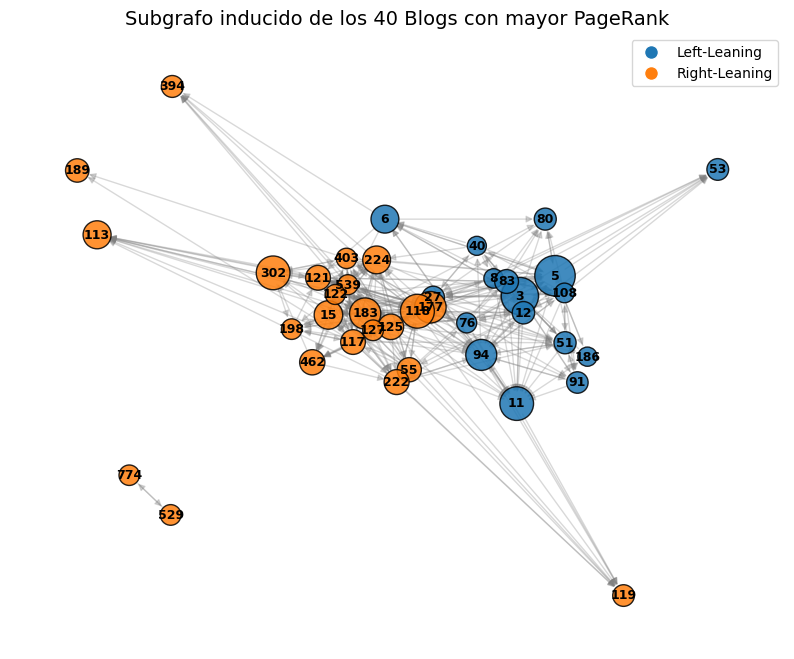

In [87]:
# Eligiendo los 40 nodos mas iportantes
top_40_pagerank = tabla_pagerank.sort_values(by="pagerank", ascending=False).head(40)["nodo"].tolist()
subgrafo = G.subgraph(top_40_pagerank)
colores_politicos = {
    "left-leaning": "#1f77b4",
    "right-leaning": "#ff7f0e",
}
dict_pagerank = dict(zip(tabla_pagerank["nodo"], tabla_pagerank["pagerank"]))

node_colors = [colores_politicos[subgrafo.nodes[nodo]["orientacion"]] for nodo in subgrafo.nodes()]
node_sizes = [dict_pagerank[nodo] * 45000 for nodo in subgrafo.nodes()]
pos = nx.spring_layout(subgrafo, k=0.4, seed=42)
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(subgrafo, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, edgecolors="black")
nx.draw_networkx_edges(subgrafo, pos, alpha=0.3, edge_color="grey")
nx.draw_networkx_labels(subgrafo, pos, font_size=9, font_weight="bold")

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Left-Leaning', markerfacecolor=colores_politicos["left-leaning"], markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Right-Leaning', markerfacecolor=colores_politicos["right-leaning"], markersize=10)
                   ]


plt.legend(handles=legend_elements, loc="upper right")
plt.title("Subgrafo inducido de los 40 Blogs con mayor PageRank", fontsize=14)
plt.axis("off")

plt.savefig(f"./figures/p5d_subgrafo_top_40_pagerank.png", dpi=300, bbox_inches="tight")
plt.show()



### P7. Interpretación de resultados

**(a) Autoridad vs. Popularidad (Análisis de PageRank)**
Los nodos con mayor PageRank representan a los verdaderos líderes de opinión de la red. A diferencia del simple grado de entrada (que solo mide la cantidad de citas), el PageRank destaca a aquellos blogs que son enlazados por otros nodos que *también* son altamente influyentes. 

**(b) Estructura del subgrafo inducido**
La visualización de los 40 blogs principales revela una topología altamente fragmentada. El algoritmo de diseño espacial agrupa a los nodos en dos conglomerados fuertemente separados, evidenciando una alta densidad de conexiones internas y una casi nula existencia de "puentes" entre ambos grupos.

**(c) Polarización y "Cámaras de Eco"**
Al cruzar esta estructura topológica con la orientación política, concluimos que:
1. **Influencia equitativa:** El dominio de la red no pertenece a un solo sector; la élite del PageRank se reparte de forma casi simétrica entre los bloques *left-leaning* y *right-leaning*.
2. **Homofilia ideológica:** Los enlaces fluyen casi exclusivamente hacia nodos de la misma orientación política. Esto demuestra cuantitativamente la existencia de **"cámaras de eco"** (*echo chambers*), donde la información circula en burbujas cerradas, reflejando la extrema polarización del debate político de la época.

## P8: Discusión, limitaciones y conclusiones
## 1. Respuesta a la pregunta e hipótesis inicial

**Evaluación de la hipótesis:** La hipótesis inicial planteaba que los blogs con mayor cantidad de citas (grado de entrada) serían los más influyentes de la red. Los resultados demuestran que esta hipótesis se cumple solo parcialmente. Si bien existe una altísima correlación lineal (0.9555) entre ambas métricas, el algoritmo identificó anomalías clave. Nodos como el 189 demostraron que recibir pocos enlaces provenientes de la "élite" de la red otorga mayor centralidad que acumular cientos de enlaces de sitios irrelevantes.

**Respuesta a la pregunta principal:** El análisis respondió exitosamente cuáles son los líderes de opinión. Se logró identificar que el dominio de la red está equitativamente distribuido entre orientaciones políticas (Top 50: 56% derecha, 44% izquierda), evidenciando que ningún sector ideológico monopoliza la influencia total.

## 2. Limitaciones del método y de los datos
Al aplicar el modelo de la Matriz de Google a esta red de blogs, es necesario considerar ciertas limitaciones teóricas y prácticas:

**Supuesto de marcha aleatoria:** El algoritmo asume que con una probabilidad de $1-\alpha$ (en este caso 15%), un usuario puede saltar de forma uniforme a cualquier nodo de la red. En un contexto político, es poco probable que un lector de una ideología determinada salte aleatoriamente a un blog del extremo opuesto, lo que sugiere que el modelo podría sobreestimar la conectividad global.  

**Impacto de los nodos colgantes:**La red presenta un 12.99% de nodos colgantes, los cuales carecen de enlaces de salida. Esto nos obligó a realizar una imputación mediante la matriz columna-estocástica $S$ para evitar que la probabilidad de la marcha aleatoria se perdiera.  

**Naturaleza estática:** Los datos corresponden a una fotografía fija de la red en 2004, lo que impide observar cómo evolucionó la influencia política a medida que avanzaba el proceso electoral.  

## 3. Nuevas preguntas surgidas del análisisEl fenómeno de polarización observado (la creación de "cámaras de eco") nos lleva a plantear las siguientes interrogantes para futuros estudios:
**¿Cuáles son las características estructurales de los escasos nodos "puente" que logran conectar clústeres de distintas orientaciones ideológicas?** 

**¿Cómo cambiaría la jerarquía de influencia si el factor de amortiguamiento $\alpha$ se ajustara dinámicamente según la afinidad política de los blogs?**

## 4. Si tuviéramos que explicar nuestro hallazgo principal a alguien sin conocimientos técnicos, diríamos lo siguiente:

"La red de blogs de 2004 funcionaba como un sistema donde tu influencia no dependía solo de cuántas veces te mencionaban, sino de quién te mencionaba. Al analizar este flujo de citas, descubrimos que la red estaba altamente polarizada: los blogs de izquierda y derecha formaban burbujas cerradas o 'cámaras de eco'. Básicamente, los grupos políticos se hablaban principalmente a sí mismos, validando sus propias ideas, lo que explica por qué la influencia política en la web de esa época ya estaba segmentada en bloques casi impenetrables entre sí."